# Bird OpenGenes homologs promoter pipeline

Ноутбук для:
1. извлечения промоторной последовательности относительно TSS из `GFF` + `FNA`,
2. расчёта CpG / CpA / GC-метрик,
3. классификации промоторов по Weber et al. (`HCP` / `ICP` / `LCP`).

Логика пайплайна:
- из `sseqid` извлекается `species_token` и `protein_id (XP_...)`;
- по `XP_...` в `GFF` ищется родительский транскрипт `XM_...`;
- по `mRNA`-строке этого транскрипта извлекаются `seqid`, `strand`, координаты и `gene_name`;
- TSS определяется на уровне транскрипта:
  - `+` strand → `TSS = start`
  - `-` strand → `TSS = end`
- из genomic `FNA` по `seqid` вытаскивается окно промотора относительно TSS;
- для `-` strand последовательность разворачивается в 5'→3' ориентацию гена через reverse-complement.

> Важно: окно промотора задаётся **параметрами в первой кодовой ячейке**.


In [6]:
from pathlib import Path
from urllib.parse import urlsplit
import gzip
import math
import re
from collections import defaultdict

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# =========================
# ПАРАМЕТРЫ ПАЙПЛАЙНА
# =========================

# Входные таблицы
HOMOLOGS_CSV_PATH = "homology_results_with_LQ.csv"
SPECIES_FILES_CSV_PATH = "~/ftp_catalogs_faa_for_weighted_fixed.csv"

# Директории с файлами геномов
GENOMIC_FNA_DIR = Path("~/genomic_fna").expanduser()
GENOMIC_GFF_DIR = Path("~/genomic_gff").expanduser()

# Колонки
SSEQID_COL = "sseqid"
GENUS_COL = "Genus"
SPECIES_COL = "Species"
GENOMIC_FNA_URL_COL = "genomic_fna_url"
GENOMIC_GFF_URL_COL = "genomic_gff_url"

# Окно промотора относительно TSS (включительно!)
# Пример: -400 .. +100
PROMOTER_REL_START = -499
PROMOTER_REL_END = 100

# Параметры Weber et al. для классификации промоторов
WEBER_WINDOW_BP = 500
HCP_CPG_RATIO_THRESHOLD = 0.75
HCP_GC_CONTENT_THRESHOLD = 55.0
LCP_CPG_RATIO_THRESHOLD = 0.48

# Выход
OUTPUT_CSV_PATH = "homologs_with_promoter_metrics_easy-search.csv"

# Прочее
TQDM_DISABLE = False


print("PARAMETERS READY")
print(f"Promoter window: {PROMOTER_REL_START} .. {PROMOTER_REL_END} relative to TSS (inclusive)")
print(f"Expected promoter length: {PROMOTER_REL_END - PROMOTER_REL_START + 1} bp")


PARAMETERS READY
Promoter window: -499 .. 100 relative to TSS (inclusive)
Expected promoter length: 600 bp


## 1. вычленить последовательность промотора как -400 до 100 от TSS (для этого нужно посмотреть на sseqid и вычленить оттуда название гена-гомолога типа XP_037989541.1 и найти его в файле с полногеномной последовательностью для данного вида. учти что есть отдельный датафрейм содеражащий соответствие вид--название файла)

На этом этапе:
- загружаются таблицы,
- строятся `gff_path` и `fna_path` из URL,
- из `sseqid` извлекаются `species_token` и `protein_id`,
- для каждого `XP_...` в `GFF` ищется родительский `XM_...`,
- из `mRNA`-строки берётся TSS,
- из `FNA` извлекается промоторная последовательность.


In [7]:
def open_maybe_gzip(path, mode="rt"):
    path = str(path)
    if path.endswith(".gz"):
        return gzip.open(path, mode)
    return open(path, mode)

def basename_from_url(url):
    if pd.isna(url):
        return np.nan
    return Path(urlsplit(str(url)).path).name

def parse_sseqid(value):
    """
    Пример:
    Motacilla_alba_alba|XP_037989541.1 -> ("Motacilla_alba_alba", "XP_037989541.1")
    """
    if pd.isna(value):
        return (np.nan, np.nan)
    parts = str(value).split("|", 1)
    if len(parts) != 2:
        return (np.nan, np.nan)
    return parts[0], parts[1]

def make_species_key_from_token(species_token):
    """
    Сводим species_token из sseqid к ключу Genus_Species.
    Например: Motacilla_alba_alba -> Motacilla_alba
    """
    if pd.isna(species_token):
        return np.nan
    parts = str(species_token).split("_")
    if len(parts) < 2:
        return np.nan
    return "_".join(parts[:2])

def parse_gff_attributes(attr_str):
    attrs = {}
    for item in str(attr_str).split(";"):
        if not item:
            continue
        if "=" in item:
            key, value = item.split("=", 1)
            attrs[key] = value
    return attrs

def strip_known_prefix(value):
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return None
    value = str(value)
    for prefix in ("rna-", "cds-", "gene-"):
        if value.startswith(prefix):
            return value[len(prefix):]
    return value

def extract_parent_transcript(attrs):
    parent = attrs.get("Parent")
    if not parent:
        return None
    first_parent = str(parent).split(",")[0]
    return strip_known_prefix(first_parent)

def get_gene_name(attrs):
    return attrs.get("gene") or attrs.get("gene_name") or attrs.get("Name")

def reverse_complement(seq):
    comp = str.maketrans("ACGTNacgtn", "TGCANtgcan")
    return seq.translate(comp)[::-1]

def compute_tss(start, end, strand):
    if strand == "+":
        return int(start)
    if strand == "-":
        return int(end)
    return np.nan

def compute_promoter_interval(tss, strand, rel_start, rel_end):
    """
    Координаты GFF/FNA считаем 1-based inclusive.
    Окно задаётся относительно TSS в координатах гена (тоже inclusive).

    Для '+' strand:
        genomic_start = TSS + rel_start
        genomic_end   = TSS + rel_end

    Для '-' strand:
        genomic_start = TSS - rel_end
        genomic_end   = TSS - rel_start
    """
    if pd.isna(tss):
        return (np.nan, np.nan)
    tss = int(tss)
    if strand == "+":
        return (tss + rel_start, tss + rel_end)
    if strand == "-":
        return (tss - rel_end, tss - rel_start)
    return (np.nan, np.nan)

def read_fasta_subset(fna_path, needed_seqids):
    """
    Сканирует FNA один раз и сохраняет только те записи, которые реально нужны.
    Работает и для .fna, и для .fna.gz.
    """
    needed_seqids = set(x for x in needed_seqids if pd.notna(x))
    sequences = {}

    current_id = None
    current_chunks = None

    with open_maybe_gzip(fna_path, "rt") as fh:
        for line in fh:
            line = line.rstrip("\n")
            if not line:
                continue

            if line.startswith(">"):
                if current_id in needed_seqids and current_chunks is not None:
                    sequences[current_id] = "".join(current_chunks).upper()

                header = line[1:].strip()
                seqid = header.split()[0]

                current_id = seqid
                current_chunks = [] if seqid in needed_seqids else None
            else:
                if current_chunks is not None:
                    current_chunks.append(line.strip())

        if current_id in needed_seqids and current_chunks is not None:
            sequences[current_id] = "".join(current_chunks).upper()

    return sequences


In [8]:
def build_gff_index(gff_path):
    """
    Строит индексы:
    - protein_id (XP_...) -> transcript_id (XM_...)
    - transcript_id (XM_...) -> mRNA record
    - transcript_id fallback по exon bounds
    - transcript_id fallback по CDS bounds
    """
    protein_to_transcript = {}
    protein_to_gene = {}

    transcript_to_mrna = {}

    exon_bounds = {}
    cds_bounds = {}

    with open_maybe_gzip(gff_path, "rt") as fh:
        for line in fh:
            if not line or line.startswith("#"):
                continue

            cols = line.rstrip("\n").split("\t")
            if len(cols) < 9:
                continue

            seqid, source, feature, start, end, score, strand, phase, attr_str = cols
            start, end = int(start), int(end)
            attrs = parse_gff_attributes(attr_str)

            gene_name = get_gene_name(attrs)

            if feature in {"mRNA", "transcript"}:
                transcript_ids = set()

                if "transcript_id" in attrs:
                    transcript_ids.add(strip_known_prefix(attrs["transcript_id"]))
                if "Name" in attrs:
                    transcript_ids.add(strip_known_prefix(attrs["Name"]))
                if "ID" in attrs:
                    transcript_ids.add(strip_known_prefix(attrs["ID"]))

                rec = {
                    "seqid": seqid,
                    "start": start,
                    "end": end,
                    "strand": strand,
                    "gene_name": gene_name,
                    "feature_source": feature,
                }

                for tid in transcript_ids:
                    if tid:
                        transcript_to_mrna[tid] = rec

            elif feature == "exon":
                tid = extract_parent_transcript(attrs)
                if tid:
                    if tid not in exon_bounds:
                        exon_bounds[tid] = {
                            "seqid": seqid,
                            "start": start,
                            "end": end,
                            "strand": strand,
                            "gene_name": gene_name,
                        }
                    else:
                        exon_bounds[tid]["start"] = min(exon_bounds[tid]["start"], start)
                        exon_bounds[tid]["end"] = max(exon_bounds[tid]["end"], end)

            elif feature == "CDS":
                tid = extract_parent_transcript(attrs)
                protein_id = attrs.get("protein_id") or strip_known_prefix(attrs.get("Name"))
                if protein_id and tid and protein_id not in protein_to_transcript:
                    protein_to_transcript[protein_id] = tid
                    protein_to_gene[protein_id] = gene_name

                if tid:
                    if tid not in cds_bounds:
                        cds_bounds[tid] = {
                            "seqid": seqid,
                            "start": start,
                            "end": end,
                            "strand": strand,
                            "gene_name": gene_name,
                        }
                    else:
                        cds_bounds[tid]["start"] = min(cds_bounds[tid]["start"], start)
                        cds_bounds[tid]["end"] = max(cds_bounds[tid]["end"], end)

    # Fallback: если mRNA не найдена, пробуем восстановить transcript bounds по exon
    for tid, rec in exon_bounds.items():
        if tid not in transcript_to_mrna:
            transcript_to_mrna[tid] = {
                **rec,
                "feature_source": "exon_bounds_fallback",
            }

    # Fallback: если нет даже exon, используем CDS bounds
    for tid, rec in cds_bounds.items():
        if tid not in transcript_to_mrna:
            transcript_to_mrna[tid] = {
                **rec,
                "feature_source": "cds_bounds_fallback",
            }

    return protein_to_transcript, protein_to_gene, transcript_to_mrna


In [9]:
# 1.1 Загрузка исходных таблиц и подготовка путей

homologs_df = pd.read_csv(HOMOLOGS_CSV_PATH)
species_files_df = pd.read_csv(SPECIES_FILES_CSV_PATH)

species_files_df = species_files_df.copy()
species_files_df["species_key"] = (
    species_files_df[GENUS_COL].astype(str).str.strip() + "_" +
    species_files_df[SPECIES_COL].astype(str).str.strip()
)

species_files_df["fna_filename"] = species_files_df[GENOMIC_FNA_URL_COL].apply(basename_from_url)
species_files_df["gff_filename"] = species_files_df[GENOMIC_GFF_URL_COL].apply(basename_from_url)

species_files_df["fna_path"] = species_files_df["fna_filename"].apply(
    lambda x: str(GENOMIC_FNA_DIR / x) if pd.notna(x) else np.nan
)
species_files_df["gff_path"] = species_files_df["gff_filename"].apply(
    lambda x: str(GENOMIC_GFF_DIR / x) if pd.notna(x) else np.nan
)

homologs_df = homologs_df.copy()
homologs_df[["species_token", "protein_id"]] = homologs_df[SSEQID_COL].apply(
    lambda x: pd.Series(parse_sseqid(x))
)
homologs_df["species_key"] = homologs_df["species_token"].apply(make_species_key_from_token)

# Мержим пути к файлам
merge_cols = ["species_key", GENUS_COL, SPECIES_COL, "fna_path", "gff_path", "fna_filename", "gff_filename"]
homologs_df = homologs_df.merge(
    species_files_df[merge_cols].drop_duplicates(subset=["species_key"]),
    on="species_key",
    how="left",
)

display(homologs_df.head())
print(f"Homolog rows: {len(homologs_df):,}")
print(f"Unique species keys in homolog table: {homologs_df['species_key'].nunique()}")


,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,...,LQ_upper,species_token,protein_id,species_key,Genus,Species,fna_path,gff_path,fna_filename,gff_filename
0,A2M,Zonotrichia_albicollis|XP_074391075.1,0.578,1471,619,0,1,1468,1,1471,...,False,Zonotrichia_albicollis,XP_074391075.1,Zonotrichia_albicollis,Zonotrichia,albicollis,/home/poroshina/genomic_fna/GCF_047830755.1_bZ...,/home/poroshina/genomic_gff/GCF_047830755.1_bZ...,GCF_047830755.1_bZonAlb1.hap1_genomic.fna.gz,GCF_047830755.1_bZonAlb1.hap1_genomic.gff.gz
1,AARS1,Zonotrichia_albicollis|XP_005490794.1,0.870,968,126,0,1,968,1,968,...,False,Zonotrichia_albicollis,XP_005490794.1,Zonotrichia_albicollis,Zonotrichia,albicollis,/home/poroshina/genomic_fna/GCF_047830755.1_bZ...,/home/poroshina/genomic_gff/GCF_047830755.1_bZ...,GCF_047830755.1_bZonAlb1.hap1_genomic.fna.gz,GCF_047830755.1_bZonAlb1.hap1_genomic.gff.gz
2,AASS,Zonotrichia_albicollis|XP_074396065.1,0.814,297,55,0,159,455,1,295,...,False,Zonotrichia_albicollis,XP_074396065.1,Zonotrichia_albicollis,Zonotrichia,albicollis,/home/poroshina/genomic_fna/GCF_047830755.1_bZ...,/home/poroshina/genomic_gff/GCF_047830755.1_bZ...,GCF_047830755.1_bZonAlb1.hap1_genomic.fna.gz,GCF_047830755.1_bZonAlb1.hap1_genomic.gff.gz
3,ABCA5,Zonotrichia_albicollis|XP_074411450.1,0.735,1556,411,0,92,1642,1,1556,...,False,Zonotrichia_albicollis,XP_074411450.1,Zonotrichia_albicollis,Zonotrichia,albicollis,/home/poroshina/genomic_fna/GCF_047830755.1_bZ...,/home/poroshina/genomic_gff/GCF_047830755.1_bZ...,GCF_047830755.1_bZonAlb1.hap1_genomic.fna.gz,GCF_047830755.1_bZonAlb1.hap1_genomic.gff.gz
4,ABCA8,Zonotrichia_albicollis|XP_074411085.1,0.446,1045,578,0,4,1048,6,1049,...,False,Zonotrichia_albicollis,XP_074411085.1,Zonotrichia_albicollis,Zonotrichia,albicollis,/home/poroshina/genomic_fna/GCF_047830755.1_bZ...,/home/poroshina/genomic_gff/GCF_047830755.1_bZ...,GCF_047830755.1_bZonAlb1.hap1_genomic.fna.gz,GCF_047830755.1_bZonAlb1.hap1_genomic.gff.gz


Homolog rows: 221,952
Unique species keys in homolog table: 107


In [10]:
from concurrent.futures import ProcessPoolExecutor, as_completed
from multiprocessing import get_context
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm

N_WORKERS = 16


def make_empty_promoter_fields(status):
    return {
        "transcript_id": np.nan,
        "gene_name_from_gff": np.nan,
        "seqid": np.nan,
        "strand": np.nan,
        "transcript_start": np.nan,
        "transcript_end": np.nan,
        "tss": np.nan,
        "promoter_start": np.nan,
        "promoter_end": np.nan,
        "promoter_len": np.nan,
        "promoter_seq": np.nan,
        "status": status,
    }


def fail_all_rows(species_subdf, status):
    out = []
    for _, row in species_subdf.iterrows():
        rec = row.to_dict()
        rec.update(make_empty_promoter_fields(status))
        out.append(rec)
    return out


def process_species_group(args):
    """
    Обрабатывает одну species-группу.
    ВАЖНО: функции build_gff_index, read_fasta_subset, compute_tss,
    compute_promoter_interval, reverse_complement должны быть уже определены.
    """
    species_key, species_subdf, promoter_rel_start, promoter_rel_end = args

    species_subdf = species_subdf.copy()

    # Если species_key не распарсился
    if pd.isna(species_key):
        return fail_all_rows(species_subdf, "species_key_not_parsed_from_sseqid")

    row0 = species_subdf.iloc[0]
    gff_path = row0.get("gff_path", np.nan)
    fna_path = row0.get("fna_path", np.nan)

    if pd.isna(gff_path):
        return fail_all_rows(species_subdf, "gff_path_not_found_for_species")

    if pd.isna(fna_path):
        return fail_all_rows(species_subdf, "fna_path_not_found_for_species")

    if not Path(gff_path).exists():
        return fail_all_rows(species_subdf, "gff_file_missing_on_disk")

    if not Path(fna_path).exists():
        return fail_all_rows(species_subdf, "fna_file_missing_on_disk")

    # Индексируем GFF для одного вида
    protein_to_transcript, protein_to_gene, transcript_to_mrna = build_gff_index(gff_path)

    temp_rows = []
    needed_seqids = set()

    for _, row in species_subdf.iterrows():
        rec = row.to_dict()

        protein_id = rec.get("protein_id", np.nan)

        if pd.isna(protein_id):
            rec.update(make_empty_promoter_fields("protein_id_not_parsed_from_sseqid"))
            temp_rows.append(rec)
            continue

        transcript_id = protein_to_transcript.get(protein_id)
        gene_name_from_gff = protein_to_gene.get(protein_id, np.nan)

        if transcript_id is None:
            rec.update({
                "transcript_id": np.nan,
                "gene_name_from_gff": gene_name_from_gff,
                "seqid": np.nan,
                "strand": np.nan,
                "transcript_start": np.nan,
                "transcript_end": np.nan,
                "tss": np.nan,
                "promoter_start": np.nan,
                "promoter_end": np.nan,
                "promoter_len": np.nan,
                "promoter_seq": np.nan,
                "status": "protein_id_not_found_in_gff_cds",
            })
            temp_rows.append(rec)
            continue

        mrna_rec = transcript_to_mrna.get(transcript_id)

        if mrna_rec is None:
            rec.update({
                "transcript_id": transcript_id,
                "gene_name_from_gff": gene_name_from_gff,
                "seqid": np.nan,
                "strand": np.nan,
                "transcript_start": np.nan,
                "transcript_end": np.nan,
                "tss": np.nan,
                "promoter_start": np.nan,
                "promoter_end": np.nan,
                "promoter_len": np.nan,
                "promoter_seq": np.nan,
                "status": "transcript_id_not_found_in_gff_mrna_or_fallback",
            })
            temp_rows.append(rec)
            continue

        seqid = mrna_rec["seqid"]
        strand = mrna_rec["strand"]
        transcript_start = mrna_rec["start"]
        transcript_end = mrna_rec["end"]
        gene_name_from_gff = mrna_rec.get("gene_name", gene_name_from_gff)

        tss = compute_tss(transcript_start, transcript_end, strand)

        promoter_start, promoter_end = compute_promoter_interval(
            tss=tss,
            strand=strand,
            rel_start=promoter_rel_start,
            rel_end=promoter_rel_end,
        )

        rec.update({
            "transcript_id": transcript_id,
            "gene_name_from_gff": gene_name_from_gff,
            "seqid": seqid,
            "strand": strand,
            "transcript_start": transcript_start,
            "transcript_end": transcript_end,
            "tss": tss,
            "promoter_start": promoter_start,
            "promoter_end": promoter_end,
            "promoter_len": (
                promoter_end - promoter_start + 1
                if pd.notna(promoter_start) and pd.notna(promoter_end)
                else np.nan
            ),
            "promoter_seq": np.nan,
            "status": "coordinates_ready",
            "_feature_source": mrna_rec.get("feature_source"),
        })

        if pd.notna(seqid):
            needed_seqids.add(seqid)

        temp_rows.append(rec)

    # Загружаем только нужные seqid из FNA
    seqid_to_sequence = read_fasta_subset(fna_path, needed_seqids)

    out_records = []

    for rec in temp_rows:
        if rec["status"] != "coordinates_ready":
            out_records.append(rec)
            continue

        seqid = rec["seqid"]
        strand = rec["strand"]
        promoter_start = rec["promoter_start"]
        promoter_end = rec["promoter_end"]

        genome_seq = seqid_to_sequence.get(seqid)

        if genome_seq is None:
            rec["status"] = "seqid_not_found_in_fna"
            out_records.append(rec)
            continue

        if promoter_start < 1 or promoter_end > len(genome_seq):
            rec["status"] = "promoter_out_of_bounds_in_fna"
            out_records.append(rec)
            continue

        subseq = genome_seq[promoter_start - 1 : promoter_end]

        if strand == "-":
            subseq = reverse_complement(subseq)
        elif strand != "+":
            rec["status"] = "invalid_strand"
            out_records.append(rec)
            continue

        rec["promoter_seq"] = subseq.upper()
        rec["status"] = "ok"
        out_records.append(rec)

    return out_records


# =============================================================================
# 1.2 Извлечение промоторов по species-группам — parallel version
# =============================================================================

group_iter = list(homologs_df.groupby("species_key", dropna=False))

tasks = [
    (species_key, species_subdf, PROMOTER_REL_START, PROMOTER_REL_END)
    for species_key, species_subdf in group_iter
]

records = []

ctx = get_context("fork")

with ProcessPoolExecutor(max_workers=N_WORKERS, mp_context=ctx) as executor:
    futures = [executor.submit(process_species_group, task) for task in tasks]

    for future in tqdm(
        as_completed(futures),
        total=len(futures),
        disable=TQDM_DISABLE,
        desc=f"Extracting promoters with {N_WORKERS} workers",
    ):
        records.extend(future.result())

promoter_df = pd.DataFrame(records)

display(promoter_df.head())
print(promoter_df["status"].value_counts(dropna=False))

Extracting promoters with 16 workers: 100%|██████████| 107/107 [03:42<00:00,  2.08s/it]


,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,...,strand,transcript_start,transcript_end,tss,promoter_start,promoter_end,promoter_len,promoter_seq,status,_feature_source
0,A2M,Acanthisitta_chloris|XP_009072629.1,0.443,1377,756,0,25,1401,18,1376,...,+,119245.0,147513.0,119245.0,118746.0,119345.0,600.0,TCCTCCTGTGCCACTCTGAATGCATGTATAGATGTATTCTTTTTGA...,ok,mRNA
1,AARS1,Acanthisitta_chloris|XP_009072409.1,0.847,977,148,0,1,968,1,977,...,-,76.0,13935.0,13935.0,13835.0,14434.0,600.0,AATACCTAATCTAACCCTGTCTTCTGTCAGTTTGAAGCCATTCCCC...,ok,mRNA
2,AASS,Acanthisitta_chloris|XP_009074733.1,0.802,455,90,0,1,455,1,454,...,+,1538.0,28434.0,1538.0,1039.0,1638.0,600.0,AAAAACACTTGGCATTGGTCTTATATTGGGCTTTTCCTTTTAATTA...,ok,mRNA
3,ABCA8,Acanthisitta_chloris|XP_009078667.1,0.416,907,523,0,152,1048,4,910,...,+,661.0,21117.0,661.0,162.0,761.0,600.0,ATTGATCCATGGAGGTTGTTTTCAGGGTGTACCTTGGGGTCAACTG...,ok,mRNA
4,ABCA9,Acanthisitta_chloris|XP_009078410.1,0.484,1448,745,0,16,1463,166,1610,...,+,39939.0,60428.0,39939.0,39440.0,40039.0,600.0,ACCCTCACTCTAGAAAGGATTTTAACACCACAGCCAGGAGTTGCTC...,ok,mRNA


status
ok                               216069
promoter_out_of_bounds_in_fna      3799
fna_file_missing_on_disk           2084
Name: count, dtype: int64


In [11]:
promoter_df

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,...,strand,transcript_start,transcript_end,tss,promoter_start,promoter_end,promoter_len,promoter_seq,status,_feature_source
0,A2M,Acanthisitta_chloris|XP_009072629.1,0.443,1377,756,0,25,1401,18,1376,...,+,119245.0,147513.0,119245.0,118746.0,119345.0,600.0,TCCTCCTGTGCCACTCTGAATGCATGTATAGATGTATTCTTTTTGA...,ok,mRNA
1,AARS1,Acanthisitta_chloris|XP_009072409.1,0.847,977,148,0,1,968,1,977,...,-,76.0,13935.0,13935.0,13835.0,14434.0,600.0,AATACCTAATCTAACCCTGTCTTCTGTCAGTTTGAAGCCATTCCCC...,ok,mRNA
2,AASS,Acanthisitta_chloris|XP_009074733.1,0.802,455,90,0,1,455,1,454,...,+,1538.0,28434.0,1538.0,1039.0,1638.0,600.0,AAAAACACTTGGCATTGGTCTTATATTGGGCTTTTCCTTTTAATTA...,ok,mRNA
3,ABCA8,Acanthisitta_chloris|XP_009078667.1,0.416,907,523,0,152,1048,4,910,...,+,661.0,21117.0,661.0,162.0,761.0,600.0,ATTGATCCATGGAGGTTGTTTTCAGGGTGTACCTTGGGGTCAACTG...,ok,mRNA
4,ABCA9,Acanthisitta_chloris|XP_009078410.1,0.484,1448,745,0,16,1463,166,1610,...,+,39939.0,60428.0,39939.0,39440.0,40039.0,600.0,ACCCTCACTCTAGAAAGGATTTTAACACCACAGCCAGGAGTTGCTC...,ok,mRNA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221947,ZNF592,Zonotrichia_albicollis|XP_074405808.1,0.610,1238,477,0,1,1224,1,1238,...,-,18616035.0,18656797.0,18656797.0,18656697.0,18657296.0,600.0,AGGGATGGAAGCCCTTAGTAACCTGTGCTGACAGATCCCAGGCATC...,ok,mRNA
221948,ZNF652,Zonotrichia_albicollis|XP_074414028.1,0.526,601,192,0,20,426,12,612,...,-,926597.0,959135.0,959135.0,959035.0,959634.0,600.0,AAGGGGCGGGCGCGCGGGAACGGCCCCCGGCGGCGCATGCGCACAG...,ok,mRNA
221949,ZSCAN5A,Zonotrichia_albicollis|XP_005480418.2,0.486,76,38,0,402,477,898,971,...,-,14905215.0,15025313.0,15025313.0,15025213.0,15025812.0,600.0,GCCCGCAGCGCAGCGCGCCCCGCCAGGTGCGAGCCGAGCCCCGCGG...,ok,mRNA
221950,ZW10,Zonotrichia_albicollis|XP_005495501.2,0.637,772,258,0,3,715,7,778,...,+,1194883.0,1203342.0,1194883.0,1194384.0,1194983.0,600.0,TCCACTGATGGATACCCCAGCCAGGAAACACTGCAGAGCTGGGGAG...,ok,mRNA


## 1.1 
тут нужен квалити чек на N в последовательности, потому что если их много, статистика начинает плыть. пока иключу все, где N>0.05

In [12]:
N_FRACTION_SOFT_THRESHOLD = 0.05   # 5% N
import re

def compute_qc_status(seq: str,
                      n_fraction_soft_threshold: float = 0.05,
                      max_n_run_soft_threshold: int = 10) -> str:
    if not isinstance(seq, str) or len(seq) == 0:
        return "missing_promoter_seq"

    seq = seq.upper()
    n_fraction = seq.count("N") / len(seq)
    max_n_run = max((len(m.group(0)) for m in re.finditer(r"N+", seq)), default=0)

    if (n_fraction > n_fraction_soft_threshold) or (max_n_run >= max_n_run_soft_threshold):
        return "soft_flag_many_N"

    return "ok"

In [13]:
N_FRACTION_SOFT_THRESHOLD = 0.05 
MAX_N_RUN_SOFT_THRESHOLD = 10# 5% N
promoter_df["qc_status"] = promoter_df["promoter_seq"].apply(
    lambda s: compute_qc_status(
        s,
        n_fraction_soft_threshold=N_FRACTION_SOFT_THRESHOLD,
        max_n_run_soft_threshold=MAX_N_RUN_SOFT_THRESHOLD
    )
)
promoter_df[promoter_df["qc_status"]=='ok']

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,...,transcript_start,transcript_end,tss,promoter_start,promoter_end,promoter_len,promoter_seq,status,_feature_source,qc_status
0,A2M,Acanthisitta_chloris|XP_009072629.1,0.443,1377,756,0,25,1401,18,1376,...,119245.0,147513.0,119245.0,118746.0,119345.0,600.0,TCCTCCTGTGCCACTCTGAATGCATGTATAGATGTATTCTTTTTGA...,ok,mRNA,ok
1,AARS1,Acanthisitta_chloris|XP_009072409.1,0.847,977,148,0,1,968,1,977,...,76.0,13935.0,13935.0,13835.0,14434.0,600.0,AATACCTAATCTAACCCTGTCTTCTGTCAGTTTGAAGCCATTCCCC...,ok,mRNA,ok
2,AASS,Acanthisitta_chloris|XP_009074733.1,0.802,455,90,0,1,455,1,454,...,1538.0,28434.0,1538.0,1039.0,1638.0,600.0,AAAAACACTTGGCATTGGTCTTATATTGGGCTTTTCCTTTTAATTA...,ok,mRNA,ok
3,ABCA8,Acanthisitta_chloris|XP_009078667.1,0.416,907,523,0,152,1048,4,910,...,661.0,21117.0,661.0,162.0,761.0,600.0,ATTGATCCATGGAGGTTGTTTTCAGGGTGTACCTTGGGGTCAACTG...,ok,mRNA,ok
4,ABCA9,Acanthisitta_chloris|XP_009078410.1,0.484,1448,745,0,16,1463,166,1610,...,39939.0,60428.0,39939.0,39440.0,40039.0,600.0,ACCCTCACTCTAGAAAGGATTTTAACACCACAGCCAGGAGTTGCTC...,ok,mRNA,ok
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221947,ZNF592,Zonotrichia_albicollis|XP_074405808.1,0.610,1238,477,0,1,1224,1,1238,...,18616035.0,18656797.0,18656797.0,18656697.0,18657296.0,600.0,AGGGATGGAAGCCCTTAGTAACCTGTGCTGACAGATCCCAGGCATC...,ok,mRNA,ok
221948,ZNF652,Zonotrichia_albicollis|XP_074414028.1,0.526,601,192,0,20,426,12,612,...,926597.0,959135.0,959135.0,959035.0,959634.0,600.0,AAGGGGCGGGCGCGCGGGAACGGCCCCCGGCGGCGCATGCGCACAG...,ok,mRNA,ok
221949,ZSCAN5A,Zonotrichia_albicollis|XP_005480418.2,0.486,76,38,0,402,477,898,971,...,14905215.0,15025313.0,15025313.0,15025213.0,15025812.0,600.0,GCCCGCAGCGCAGCGCGCCCCGCCAGGTGCGAGCCGAGCCCCGCGG...,ok,mRNA,ok
221950,ZW10,Zonotrichia_albicollis|XP_005495501.2,0.637,772,258,0,3,715,7,778,...,1194883.0,1203342.0,1194883.0,1194384.0,1194983.0,600.0,TCCACTGATGGATACCCCAGCCAGGAAACACTGCAGAGCTGGGGAG...,ok,mRNA,ok


In [10]:
len(promoter_df[promoter_df["qc_status"]=='ok'])/len(promoter_df)

0.9320213379469435

In [11]:
promoter_df=promoter_df[promoter_df["qc_status"]=='ok']

## 2. считаем cpg cpa и cg-контент

На этом этапе по извлечённой промоторной последовательности считаются:
- число `CpG`,
- число `CpA`,
- число `C`, `G`, `GC`,
- `GC content (%)`,
- `CpG ratio` по формуле Weber et al.:

\[
\text{CpG ratio} = \frac{N_{CpG} \times L}{N_C \times N_G}
\]

где:
- \(N_{CpG}\) — число динуклеотидов `CG`,
- \(L\) — длина последовательности,
- \(N_C\) — число `C`,
- \(N_G\) — число `G`.


In [14]:
def count_dinucleotide(seq, motif):
    if not isinstance(seq, str):
        return np.nan
    seq = seq.upper()
    motif = motif.upper()
    return sum(1 for i in range(len(seq) - 1) if seq[i:i+2] == motif)

def compute_sequence_metrics(seq):
    if not isinstance(seq, str) or len(seq) == 0:
        return {
            "promoter_seq_len": np.nan,
            "c_count": np.nan,
            "g_count": np.nan,
            "gc_count": np.nan,
            "cpg_count": np.nan,
            "cpa_count": np.nan,
            "gc_content_pct": np.nan,
            "cpg_ratio": np.nan,
        }

    seq = seq.upper()
    seq_len = len(seq)
    c_count = seq.count("C")
    g_count = seq.count("G")
    gc_count = c_count + g_count
    cpg_count = count_dinucleotide(seq, "CG")
    cpa_count = count_dinucleotide(seq, "CA")  
    gc_content_pct = (gc_count / seq_len) * 100 if seq_len > 0 else np.nan

    if c_count > 0 and g_count > 0:
        cpg_ratio = (cpg_count * seq_len) / (c_count * g_count)
    else:
        cpg_ratio = np.nan

    return {
        "promoter_seq_len": seq_len,
        "c_count": c_count,
        "g_count": g_count,
        "gc_count": gc_count,
        "cpg_count": cpg_count,
        "cpa_count": cpa_count,
        "gc_content_pct": gc_content_pct,
        "cpg_ratio": cpg_ratio,
    }

metrics_df = promoter_df.copy()

metric_values = metrics_df["promoter_seq"].apply(compute_sequence_metrics).apply(pd.Series)
metrics_df = pd.concat([metrics_df, metric_values], axis=1)

display(metrics_df.head())


,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,...,_feature_source,qc_status,promoter_seq_len,c_count,g_count,gc_count,cpg_count,cpa_count,gc_content_pct,cpg_ratio
0,A2M,Acanthisitta_chloris|XP_009072629.1,0.443,1377,756,0,25,1401,18,1376,...,mRNA,ok,600.0,104.0,126.0,230.0,2.0,46.0,38.333333,0.091575
1,AARS1,Acanthisitta_chloris|XP_009072409.1,0.847,977,148,0,1,968,1,977,...,mRNA,ok,600.0,137.0,140.0,277.0,6.0,40.0,46.166667,0.187696
2,AASS,Acanthisitta_chloris|XP_009074733.1,0.802,455,90,0,1,455,1,454,...,mRNA,ok,600.0,110.0,123.0,233.0,4.0,50.0,38.833333,0.177384
3,ABCA8,Acanthisitta_chloris|XP_009078667.1,0.416,907,523,0,152,1048,4,910,...,mRNA,ok,600.0,123.0,147.0,270.0,1.0,43.0,45.000000,0.033184
4,ABCA9,Acanthisitta_chloris|XP_009078410.1,0.484,1448,745,0,16,1463,166,1610,...,mRNA,ok,600.0,120.0,139.0,259.0,2.0,41.0,43.166667,0.071942


In [13]:
print(set(metrics_df[metrics_df['species_key']=='Lagopus_muta']['gff_path']))
print(set(metrics_df[metrics_df['species_key']=='Lagopus_muta']['gff_filename']))

print(set(metrics_df[metrics_df['species_key']=='Lagopus_muta']['gff_path']))

print(set(metrics_df[metrics_df['species_key']=='Lagopus_muta']['fna_filename']))



set()
set()
set()
set()


In [15]:
len(metrics_df["promoter_seq"][0])

600

## 3. вычисляем категорию промотора ICP LCP HCP как в статье weber

Классификация делается по **500-bp окнам**, как в Weber et al.:

- `HCP`: существует 500-bp окно, в котором
  - `CpG ratio > 0.75`
  - `GC content > 55%`
- `LCP`: **нет** 500-bp окна, в котором `CpG ratio > 0.48`
- `ICP`: всё остальное

> Если извлечённый промотор короче 500 bp, классификация помечается как `NaN`.


In [19]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, wait, FIRST_COMPLETED
import multiprocessing as mp
from tqdm.auto import tqdm

In [16]:
def classify_promoter_weber_fast(
    seq,
    window_bp=500,
    step_bp=5,
    hcp_cpg_ratio_threshold=0.75,
    hcp_gc_content_threshold=55.0,
    lcp_cpg_ratio_threshold=0.48,
):
    if not isinstance(seq, str):
        return (np.nan, np.nan, np.nan, np.nan)

    seq = seq.upper()
    n = len(seq)

    if n < window_bp:
        return (0, np.nan, np.nan, np.nan)

    if step_bp <= 0:
        raise ValueError("step_bp must be positive")

    # starts: 0, 5, 10, ..., up to valid full 500-bp window
    starts = range(0, n - window_bp + 1, step_bp)
    window_count = ((n - window_bp) // step_bp) + 1

    max_gc = np.nan
    max_ratio = np.nan

    has_hcp_window = False
    has_ratio_above_lcp = False

    windows_seen = 0

    for start in starts:
        window_seq = seq[start:start + window_bp]

        c_count = window_seq.count("C")
        g_count = window_seq.count("G")
        gc_count = c_count + g_count
        cpg_count = window_seq.count("CG")

        gc_content_pct = (gc_count / window_bp) * 100

        if pd.isna(max_gc) or gc_content_pct > max_gc:
            max_gc = gc_content_pct

        if c_count > 0 and g_count > 0:
            cpg_ratio = (cpg_count * window_bp) / (c_count * g_count)

            if pd.isna(max_ratio) or cpg_ratio > max_ratio:
                max_ratio = cpg_ratio

            if (
                cpg_ratio > hcp_cpg_ratio_threshold
                and gc_content_pct > hcp_gc_content_threshold
            ):
                has_hcp_window = True

            if cpg_ratio > lcp_cpg_ratio_threshold:
                has_ratio_above_lcp = True

        windows_seen += 1

    assert windows_seen == window_count

    if has_hcp_window:
        promoter_class = "HCP"
    elif not has_ratio_above_lcp:
        promoter_class = "LCP"
    else:
        promoter_class = "ICP"

    return (
        window_count,
        max_ratio,
        max_gc,
        promoter_class,
    )

In [17]:
N_WORKERS = 16
BATCH_SIZE = 50_000
MAX_PENDING = N_WORKERS * 2

OUT_DIR = Path("weber_classification_batches_step5")
OUT_DIR.mkdir(exist_ok=True)

WEBER_COLUMNS = [
    "weber_window_count",
    "weber_max_cpg_ratio_500bp",
    "weber_max_gc_content_500bp",
    "promoter_class_weber",
]

PARAMS = dict(
    window_bp=500,
    step_bp=5,
    hcp_cpg_ratio_threshold=HCP_CPG_RATIO_THRESHOLD,
    hcp_gc_content_threshold=HCP_GC_CONTENT_THRESHOLD,
    lcp_cpg_ratio_threshold=LCP_CPG_RATIO_THRESHOLD,
)


def process_weber_batch(start, end, seqs, params):
    rows = [
        classify_promoter_weber_fast(seq, **params)
        for seq in seqs
    ]

    batch_df = pd.DataFrame(rows, columns=WEBER_COLUMNS)
    batch_df.insert(0, "row_pos", np.arange(start, end))

    return start, end, batch_df


def run_weber_parallel(metrics_df, seq_col="promoter_seq"):
    n = len(metrics_df)
    starts = list(range(0, n, BATCH_SIZE))

    pending = {}
    submitted = 0
    completed = 0

    ctx = mp.get_context("fork")

    with ProcessPoolExecutor(max_workers=N_WORKERS, mp_context=ctx) as executor:
        pbar = tqdm(total=len(starts), desc="Weber batches step=5")

        while submitted < len(starts) or pending:
            while submitted < len(starts) and len(pending) < MAX_PENDING:
                start = starts[submitted]
                end = min(start + BATCH_SIZE, n)

                out_path = OUT_DIR / f"weber_step5_{start:09d}_{end:09d}.pkl"

                # если батч уже посчитан — пропускаем
                if out_path.exists():
                    submitted += 1
                    completed += 1
                    pbar.update(1)
                    continue

                seqs = metrics_df[seq_col].iloc[start:end].tolist()

                fut = executor.submit(
                    process_weber_batch,
                    start,
                    end,
                    seqs,
                    PARAMS,
                )

                pending[fut] = out_path
                submitted += 1

            if pending:
                done, _ = wait(pending, return_when=FIRST_COMPLETED)

                for fut in done:
                    out_path = pending.pop(fut)

                    start, end, batch_df = fut.result()
                    batch_df.to_pickle(out_path)

                    completed += 1
                    pbar.update(1)

        pbar.close()

    print(f"Done. Saved {completed} batch files to: {OUT_DIR}")

In [20]:
run_weber_parallel(metrics_df, seq_col="promoter_seq")

Weber batches step=5:   0%|          | 0/5 [00:00<?, ?it/s]

Done. Saved 5 batch files to: weber_classification_batches_step5


In [21]:
test_seq = metrics_df["promoter_seq"].dropna().iloc[0]

res = classify_promoter_weber_fast(
    test_seq,
    window_bp=500,
    step_bp=5,
    hcp_cpg_ratio_threshold=HCP_CPG_RATIO_THRESHOLD,
    hcp_gc_content_threshold=HCP_GC_CONTENT_THRESHOLD,
    lcp_cpg_ratio_threshold=LCP_CPG_RATIO_THRESHOLD,
)

print("seq len:", len(test_seq))
print("expected windows:", ((len(test_seq) - 500) // 5) + 1)
print("returned windows:", res[0])

seq len: 600
expected windows: 21
returned windows: 21


In [22]:
batch_files = sorted(OUT_DIR.glob("weber_step5_*.pkl"))

class_df = pd.concat(
    [pd.read_pickle(p) for p in batch_files],
    ignore_index=True,
)

class_df = class_df.sort_values("row_pos").reset_index(drop=True)
class_df = class_df.drop(columns=["row_pos"])

final_df = pd.concat(
    [
        metrics_df.drop(columns=["promoter_seq"], errors="ignore").reset_index(drop=True),
        class_df,
    ],
    axis=1,
)

display(final_df.head())
print(final_df["promoter_class_weber"].value_counts(dropna=False))

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,...,g_count,gc_count,cpg_count,cpa_count,gc_content_pct,cpg_ratio,weber_window_count,weber_max_cpg_ratio_500bp,weber_max_gc_content_500bp,promoter_class_weber
0,A2M,Acanthisitta_chloris|XP_009072629.1,0.443,1377,756,0,25,1401,18,1376,...,126.0,230.0,2.0,46.0,38.333333,0.091575,21.0,0.113263,39.6,LCP
1,AARS1,Acanthisitta_chloris|XP_009072409.1,0.847,977,148,0,1,968,1,977,...,140.0,277.0,6.0,40.0,46.166667,0.187696,21.0,0.183150,47.0,LCP
2,AASS,Acanthisitta_chloris|XP_009074733.1,0.802,455,90,0,1,455,1,454,...,123.0,233.0,4.0,50.0,38.833333,0.177384,21.0,0.217226,39.4,LCP
3,ABCA8,Acanthisitta_chloris|XP_009078667.1,0.416,907,523,0,152,1048,4,910,...,147.0,270.0,1.0,43.0,45.000000,0.033184,21.0,0.041408,45.6,LCP
4,ABCA9,Acanthisitta_chloris|XP_009078410.1,0.484,1448,745,0,16,1463,166,1610,...,139.0,259.0,2.0,41.0,43.166667,0.071942,21.0,0.091349,43.8,LCP


promoter_class_weber
HCP    118464
LCP     56976
ICP     40629
NaN      5883
Name: count, dtype: int64


In [23]:
final_df

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,...,g_count,gc_count,cpg_count,cpa_count,gc_content_pct,cpg_ratio,weber_window_count,weber_max_cpg_ratio_500bp,weber_max_gc_content_500bp,promoter_class_weber
0,A2M,Acanthisitta_chloris|XP_009072629.1,0.443,1377,756,0,25,1401,18,1376,...,126.0,230.0,2.0,46.0,38.333333,0.091575,21.0,0.113263,39.6,LCP
1,AARS1,Acanthisitta_chloris|XP_009072409.1,0.847,977,148,0,1,968,1,977,...,140.0,277.0,6.0,40.0,46.166667,0.187696,21.0,0.183150,47.0,LCP
2,AASS,Acanthisitta_chloris|XP_009074733.1,0.802,455,90,0,1,455,1,454,...,123.0,233.0,4.0,50.0,38.833333,0.177384,21.0,0.217226,39.4,LCP
3,ABCA8,Acanthisitta_chloris|XP_009078667.1,0.416,907,523,0,152,1048,4,910,...,147.0,270.0,1.0,43.0,45.000000,0.033184,21.0,0.041408,45.6,LCP
4,ABCA9,Acanthisitta_chloris|XP_009078410.1,0.484,1448,745,0,16,1463,166,1610,...,139.0,259.0,2.0,41.0,43.166667,0.071942,21.0,0.091349,43.8,LCP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221947,ZNF592,Zonotrichia_albicollis|XP_074405808.1,0.610,1238,477,0,1,1224,1,1238,...,264.0,427.0,54.0,21.0,71.166667,0.752928,21.0,0.803403,73.8,HCP
221948,ZNF652,Zonotrichia_albicollis|XP_074414028.1,0.526,601,192,0,20,426,12,612,...,173.0,479.0,96.0,29.0,79.833333,1.088065,21.0,1.133578,79.8,HCP
221949,ZSCAN5A,Zonotrichia_albicollis|XP_005480418.2,0.486,76,38,0,402,477,898,971,...,248.0,463.0,81.0,26.0,77.166667,0.911478,21.0,0.951777,79.4,HCP
221950,ZW10,Zonotrichia_albicollis|XP_005495501.2,0.637,772,258,0,3,715,7,778,...,152.0,390.0,50.0,45.0,65.000000,0.829279,21.0,0.950312,66.2,HCP


In [24]:
# Сохраняем итоговую таблицу
final_df.to_csv(OUTPUT_CSV_PATH, index=False)

print(f"Saved: {OUTPUT_CSV_PATH}")
print(f"Rows: {len(final_df):,}")
print(f"Columns: {len(final_df.columns)}")
print("\nStatus summary:")
print(final_df["status"].value_counts(dropna=False))


Saved: homologs_with_promoter_metrics_easy-search.csv
Rows: 221,952
Columns: 51

Status summary:
status
ok                               216069
promoter_out_of_bounds_in_fna      3799
fna_file_missing_on_disk           2084
Name: count, dtype: int64


In [67]:
plot_df.columns

Index(['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart',
       'qend', 'sstart', 'send', 'evalue', 'bitscore', 'teg', 'tag', 'species',
       'LQ', 'LQ_upper', 'species_token', 'protein_id', 'species_key', 'Genus',
       'Species', 'fna_path', 'gff_path', 'fna_filename', 'gff_filename',
       'transcript_id', 'gene_name_from_gff', 'seqid', 'strand',
       'transcript_start', 'transcript_end', 'tss', 'promoter_start',
       'promoter_end', 'promoter_len', 'status', '_feature_source',
       'qc_status', 'promoter_seq_len', 'c_count', 'g_count', 'gc_count',
       'cpg_count', 'cpa_count', 'gc_content_pct', 'cpg_ratio',
       'weber_window_count', 'weber_max_cpg_ratio_500bp',
       'weber_max_gc_content_500bp', 'promoter_class_weber',
       'cpg_density_per_100bp'],
      dtype='object')

In [81]:
plot_df['cpa_count'].mean()/plot_df['promoter_len'].mean()*100


np.float64(5.749403795085982)

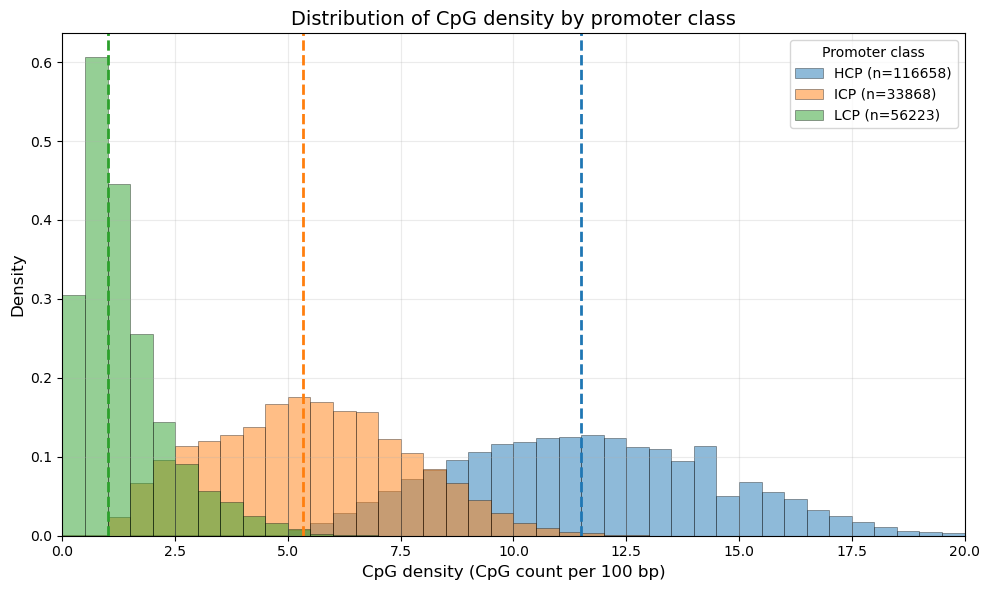

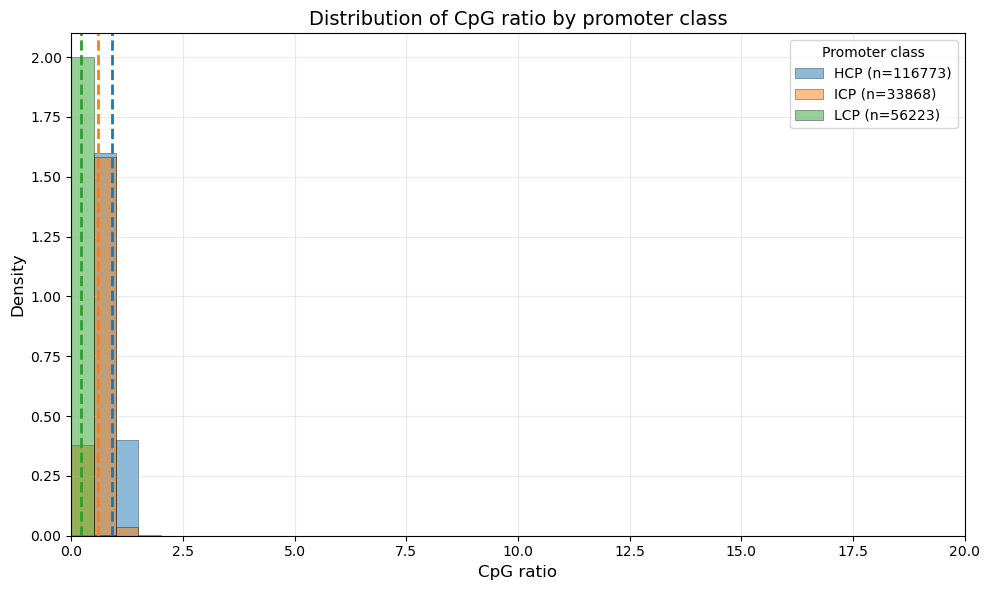

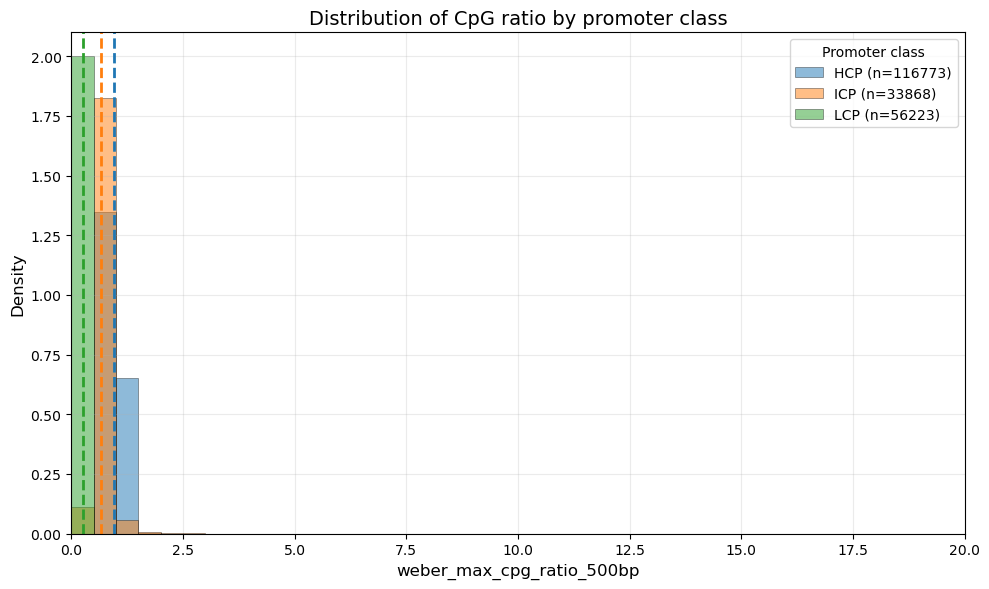

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Параметры
# =========================
DF = final_df.copy()

USE_ONLY_QC_OK = True
CLASS_COL = "promoter_class_weber"
CPG_RATIO_COL = "cpg_ratio"
CPG_COUNT_COL = "cpg_count"
PROMOTER_LEN_COL = "promoter_len"
QC_STATUS_COL = "qc_status"

# если cpg_density уже есть — будет использована;
# если нет — создадим как число CpG на 100 bp
CPG_DENSITY_COL = "cpg_density_per_100bp"

CLASS_ORDER = ["HCP", "ICP", "LCP"]
CLASS_COLORS = {
    "HCP": "#1f77b4",   # синий
    "ICP": "#ff7f0e",   # оранжевый
    "LCP": "#2ca02c",   # зелёный
}

# =========================
# Подготовка данных
# =========================
if USE_ONLY_QC_OK and QC_STATUS_COL in DF.columns:
    DF = DF[DF[QC_STATUS_COL] == "ok"].copy()

# если cpg_density ещё не посчитана — считаем как CpG на 100 bp
if CPG_DENSITY_COL not in DF.columns:
    DF[CPG_DENSITY_COL] = np.where(
        DF[PROMOTER_LEN_COL].notna() & (DF[PROMOTER_LEN_COL] > 0),
        DF[CPG_COUNT_COL] / DF[PROMOTER_LEN_COL] * 100,
        np.nan
    )
DF['cpa_density'] = np.where(
        DF[PROMOTER_LEN_COL].notna() & (DF[PROMOTER_LEN_COL] > 0),
        DF['cpa_count'] / DF[PROMOTER_LEN_COL] * 100,
        np.nan
    )
# оставляем только нужные классы и валидные значения
plot_df = DF[
    DF[CLASS_COL].isin(CLASS_ORDER)
].copy()

plot_df[CLASS_COL] = pd.Categorical(plot_df[CLASS_COL], categories=CLASS_ORDER, ordered=True)

# =========================
# Функция красивой гистограммы
# =========================
def plot_hist_by_class(
    df: pd.DataFrame,
    value_col: str,
    title: str,
    xlabel: str,
    bins: int = 40,
    xlim=[0, 20]
):
    plt.figure(figsize=(10, 6))

    # Берём все значения сразу, чтобы сделать ОБЩИЕ бины
    all_values = df.loc[
        df[CLASS_COL].isin(CLASS_ORDER),
        value_col
    ].dropna()

    if xlim is not None:
        all_values = all_values[(all_values >= xlim[0]) & (all_values <= xlim[1])]
        bin_edges = np.linspace(xlim[0], xlim[1], bins + 1)
    else:
        bin_edges = np.linspace(all_values.min(), all_values.max(), bins + 1)

    for cls in CLASS_ORDER:
        sub = df.loc[df[CLASS_COL] == cls, value_col].dropna()

        if xlim is not None:
            sub = sub[(sub >= xlim[0]) & (sub <= xlim[1])]

        if len(sub) == 0:
            continue

        plt.hist(
            sub,
            bins=bin_edges,          # <-- одинаковые границы бинов для всех классов
            alpha=0.5,
            density=True,
            label=f"{cls} (n={len(sub)})",
            color=CLASS_COLORS[cls],
            edgecolor="black",
            linewidth=0.5
        )

        median_val = sub.median()
        plt.axvline(
            median_val,
            color=CLASS_COLORS[cls],
            linestyle="--",
            linewidth=2
        )

    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.legend(title="Promoter class", frameon=True)
    plt.grid(alpha=0.25)

    if xlim is not None:
        plt.xlim(xlim)

    plt.tight_layout()
    plt.show()

# =========================
# График 1: распределение CpG-плотности
# =========================
plot_hist_by_class(
    df=plot_df,
    value_col="cpg_density_per_100bp",
    title="Distribution of CpG density by promoter class",
    xlabel="CpG density (CpG count per 100 bp)",
    bins=40
)

# =========================
# График 2: распределение CpG ratio
# =========================
plot_hist_by_class(
    df=plot_df,
    value_col=CPG_RATIO_COL,
    title="Distribution of CpG ratio by promoter class",
    xlabel="CpG ratio",
    bins=40
)


plot_hist_by_class(
    df=plot_df,
    value_col='weber_max_cpg_ratio_500bp',
    title="Distribution of CpG ratio by promoter class",
    xlabel='weber_max_cpg_ratio_500bp',
    bins=40
)

In [ ]:
final_df

In [ ]:
set(final_df['promoter_len'])

In [38]:
final_df.columns

Index(['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart',
       'qend', 'sstart', 'send', 'evalue', 'bitscore', 'teg', 'tag', 'species',
       'LQ', 'LQ_upper', 'species_token', 'protein_id', 'species_key', 'Genus',
       'Species', 'fna_path', 'gff_path', 'fna_filename', 'gff_filename',
       'transcript_id', 'gene_name_from_gff', 'seqid', 'strand',
       'transcript_start', 'transcript_end', 'tss', 'promoter_start',
       'promoter_end', 'promoter_len', 'status', '_feature_source',
       'qc_status', 'promoter_seq_len', 'c_count', 'g_count', 'gc_count',
       'cpg_count', 'cpa_count', 'gc_content_pct', 'cpg_ratio',
       'weber_window_count', 'weber_max_cpg_ratio_500bp',
       'weber_max_gc_content_500bp', 'promoter_class_weber'],
      dtype='object')

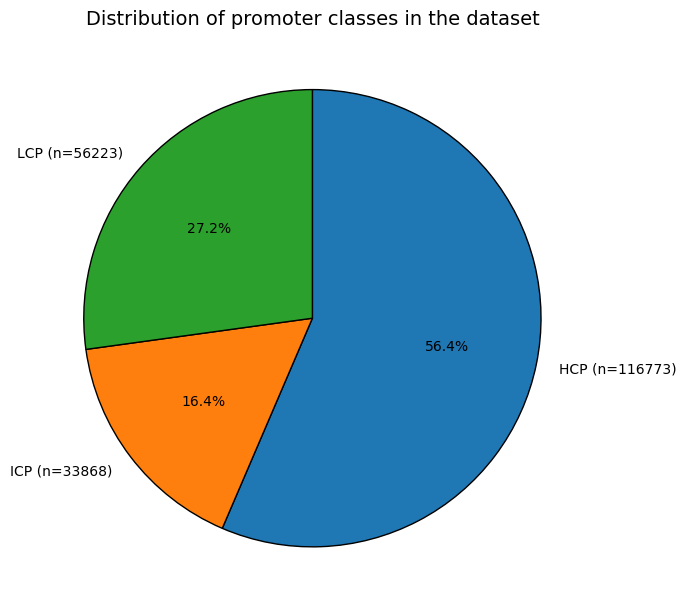

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# Параметры
# =========================
DF = final_df.copy()

USE_ONLY_QC_OK = True
CLASS_COL = "promoter_class_weber"
QC_STATUS_COL = "qc_status"

CLASS_ORDER = ["HCP", "ICP", "LCP"]

# цвета как на твоих гистограммах
CLASS_COLORS = {
    "HCP": "#1f77b4",   # синий
    "ICP": "#ff7f0e",   # оранжевый
    "LCP": "#2ca02c",   # зелёный
}

# =========================
# Подготовка
# =========================
if USE_ONLY_QC_OK and QC_STATUS_COL in DF.columns:
    DF = DF[DF[QC_STATUS_COL] == "ok"].copy()

class_counts = (
    DF[DF[CLASS_COL].isin(CLASS_ORDER)][CLASS_COL]
    .value_counts()
    .reindex(CLASS_ORDER, fill_value=0)
)

labels = [f"{cls} (n={class_counts[cls]})" for cls in CLASS_ORDER]
sizes = class_counts.values
colors = [CLASS_COLORS[cls] for cls in CLASS_ORDER]

# =========================
# Pie chart
# =========================
plt.figure(figsize=(7, 7))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)
plt.title("Distribution of promoter classes in the dataset", fontsize=14)
plt.tight_layout()
plt.show()

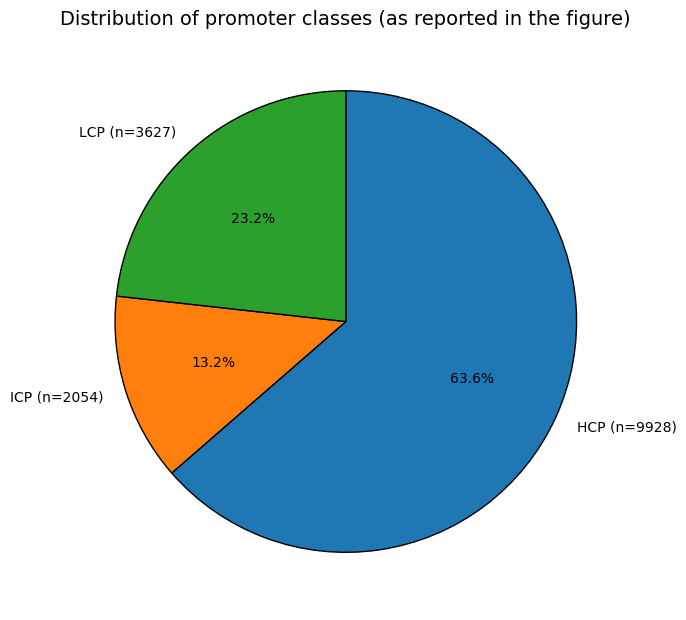

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

# counts со скрина
paper_counts = pd.Series({
    "HCP": 9928,
    "ICP": 2054,
    "LCP": 3627
})

# цвета как в описании на скрине
paper_colors = {
    "HCP": "#1f77b4",   # синий
    "ICP": "#ff7f0e",   # оранжевый
    "LCP": "#2ca02c",   # зелёный

}

order = ["HCP", "ICP", "LCP"]
labels = [f"{cls} (n={paper_counts[cls]})" for cls in order]
sizes = [paper_counts[cls] for cls in order]
colors = [paper_colors[cls] for cls in order]

plt.figure(figsize=(7, 7))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)
plt.title("Distribution of promoter classes (as reported in the figure)", fontsize=14)
plt.tight_layout()
plt.show()

In [31]:
final_df.columns

Index(['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart',
       'qend', 'sstart', 'send', 'evalue', 'bitscore', 'teg', 'tag', 'species',
       'LQ', 'LQ_upper', 'species_token', 'protein_id', 'species_key', 'Genus',
       'Species', 'fna_path', 'gff_path', 'fna_filename', 'gff_filename',
       'transcript_id', 'gene_name_from_gff', 'seqid', 'strand',
       'transcript_start', 'transcript_end', 'tss', 'promoter_start',
       'promoter_end', 'promoter_len', 'status', '_feature_source',
       'qc_status', 'promoter_seq_len', 'c_count', 'g_count', 'gc_count',
       'cpg_count', 'cpa_count', 'gc_content_pct', 'cpg_ratio',
       'weber_window_count', 'weber_max_cpg_ratio_500bp',
       'weber_max_gc_content_500bp', 'promoter_class_weber'],
      dtype='object')

In [33]:
plot_df.to_csv('plot_promotor_cpg.csv')

In [58]:
plot_df

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,...,gc_count,cpg_count,cpa_count,gc_content_pct,cpg_ratio,weber_window_count,weber_max_cpg_ratio_500bp,weber_max_gc_content_500bp,promoter_class_weber,cpg_density_per_100bp
0,A2M,Acanthisitta_chloris|XP_009072629.1,0.443,1377,756,0,25,1401,18,1376,...,230.0,2.0,46.0,38.333333,0.091575,21.0,0.113263,39.6,LCP,0.333333
1,AARS1,Acanthisitta_chloris|XP_009072409.1,0.847,977,148,0,1,968,1,977,...,277.0,6.0,40.0,46.166667,0.187696,21.0,0.183150,47.0,LCP,1.000000
2,AASS,Acanthisitta_chloris|XP_009074733.1,0.802,455,90,0,1,455,1,454,...,233.0,4.0,50.0,38.833333,0.177384,21.0,0.217226,39.4,LCP,0.666667
3,ABCA8,Acanthisitta_chloris|XP_009078667.1,0.416,907,523,0,152,1048,4,910,...,270.0,1.0,43.0,45.000000,0.033184,21.0,0.041408,45.6,LCP,0.166667
4,ABCA9,Acanthisitta_chloris|XP_009078410.1,0.484,1448,745,0,16,1463,166,1610,...,259.0,2.0,41.0,43.166667,0.071942,21.0,0.091349,43.8,LCP,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221947,ZNF592,Zonotrichia_albicollis|XP_074405808.1,0.610,1238,477,0,1,1224,1,1238,...,427.0,54.0,21.0,71.166667,0.752928,21.0,0.803403,73.8,HCP,9.000000
221948,ZNF652,Zonotrichia_albicollis|XP_074414028.1,0.526,601,192,0,20,426,12,612,...,479.0,96.0,29.0,79.833333,1.088065,21.0,1.133578,79.8,HCP,16.000000
221949,ZSCAN5A,Zonotrichia_albicollis|XP_005480418.2,0.486,76,38,0,402,477,898,971,...,463.0,81.0,26.0,77.166667,0.911478,21.0,0.951777,79.4,HCP,13.500000
221950,ZW10,Zonotrichia_albicollis|XP_005495501.2,0.637,772,258,0,3,715,7,778,...,390.0,50.0,45.0,65.000000,0.829279,21.0,0.950312,66.2,HCP,8.333333


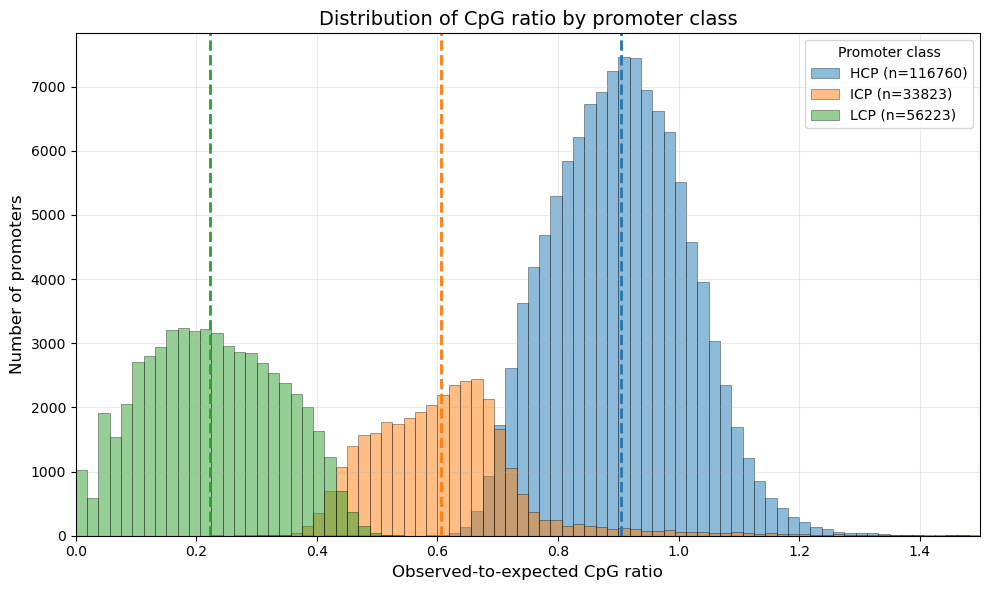

In [66]:
def plot_hist_by_class(
    df: pd.DataFrame,
    value_col: str,
    title: str,
    xlabel: str,
    bins: int = 40,
    xlim=[0, 1.5]
):
    plt.figure(figsize=(10, 6))
    # Берём все значения сразу, чтобы сделать ОБЩИЕ бины
    all_values = df.loc[
        df[CLASS_COL].isin(CLASS_ORDER),
        value_col
    ].dropna()
    if xlim is not None:
        all_values = all_values[(all_values >= xlim[0]) & (all_values <= xlim[1])]
        bin_edges = np.linspace(xlim[0], xlim[1], bins + 1)
    else:
        bin_edges = np.linspace(all_values.min(), all_values.max(), bins + 1)
    for cls in CLASS_ORDER:
        sub = df.loc[df[CLASS_COL] == cls, value_col].dropna()
        if xlim is not None:
            sub = sub[(sub >= xlim[0]) & (sub <= xlim[1])]
        if len(sub) == 0:
            continue
        plt.hist(
            sub,
            bins=bin_edges,          # одинаковые границы бинов для всех классов
            alpha=0.5,
            density=False,           # <-- было True: теперь по количеству промоторов
            label=f"{cls} (n={len(sub)})",
            color=CLASS_COLORS[cls],
            edgecolor="black",
            linewidth=0.5
        )
        median_val = sub.median()
        plt.axvline(
            median_val,
            color=CLASS_COLORS[cls],
            linestyle="--",
            linewidth=2
        )
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel("Number of promoters", fontsize=12)   # <-- было "Density"
    plt.legend(title="Promoter class", frameon=True)
    plt.grid(alpha=0.25)
    if xlim is not None:
        plt.xlim(xlim)
    plt.tight_layout()
    plt.show()


plot_hist_by_class(
    df=plot_df,
    value_col='cpg_ratio',
    title="Distribution of CpG ratio by promoter class",
    xlabel='Observed-to-expected CpG ratio',
    bins=80
)

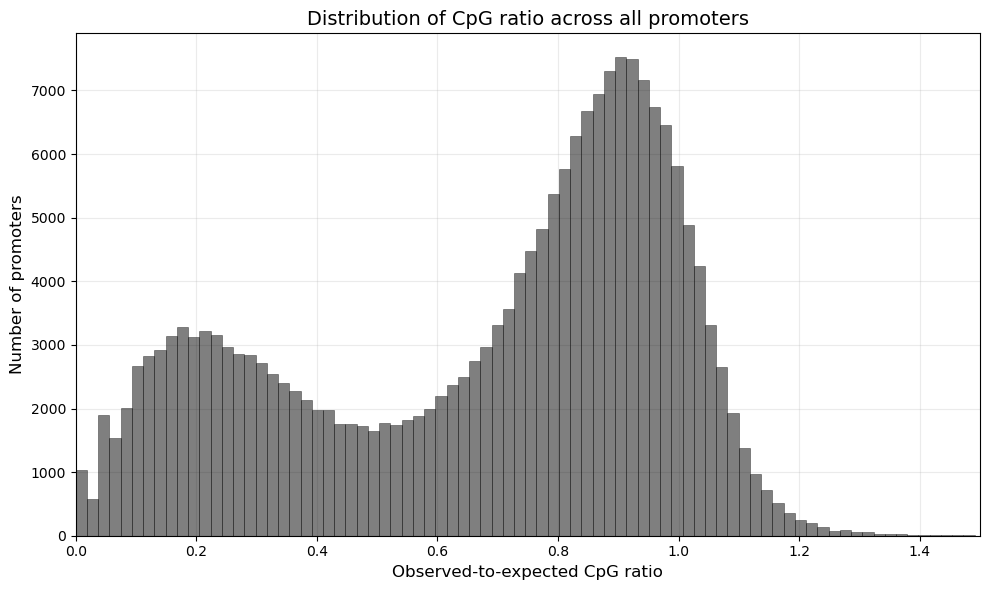

In [64]:
import numpy as np
import matplotlib.pyplot as plt

def plot_hist_overall(
    df,
    value_col='weber_max_cpg_ratio_500bp',
    title="Distribution of CpG ratio across all promoters",
    xlabel="Observed-to-expected CpG ratio",
    bins=80,
    xlim=(0, 1.6),
):
    """Одна гистограмма по всем промоторам. Без классов, без фоновой заливки."""
    vals = df[value_col].dropna()
    if xlim is not None:
        vals = vals[(vals >= xlim[0]) & (vals <= xlim[1])]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(vals, bins=bins, color="black",
            alpha=0.5, edgecolor="black", linewidth=0.5)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Number of promoters", fontsize=12)
    ax.grid(alpha=0.25)
    ax.set_axisbelow(True)
    if xlim is not None:
        ax.set_xlim(xlim)
    plt.tight_layout()
    plt.show()


plot_hist_overall(
    df=plot_df,
    value_col='cpg_ratio',
    bins=80,
    xlim=(0, 1.5),
)

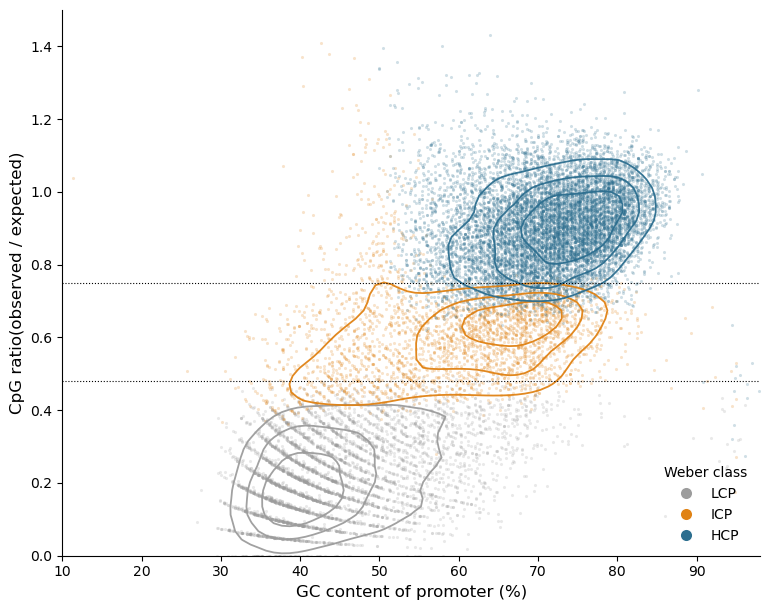

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

def plot_oe_vs_gc(
    df,
    gc_col='gc_content_pct',
    oe_col='cpg_ratio',
    class_col='promoter_class_weber',
    n_scatter=18000,
    n_kde=6000,
):
    COL = {"LCP": "#9C9C9C", "ICP": "#E08214", "HCP": "#2C6E8F"}
    ORDER = ["LCP", "ICP", "HCP"]

    fig, ax = plt.subplots(figsize=(7.8, 6.2))

    # --- облако точек (подвыборка, чтобы не плодить мегабайты) ---
    samp = df.sample(min(n_scatter, len(df)), random_state=0)
    for cls in ORDER:
        s = samp[samp[class_col] == cls]
        ax.scatter(s[gc_col], s[oe_col], s=5, alpha=0.22,
                   color=COL[cls], linewidths=0, rasterized=True)

    # --- контуры плотности по каждому классу ---
    for cls in ORDER:
        s = df[df[class_col] == cls]
        if len(s) > 500:
            sub = s.sample(min(n_kde, len(s)), random_state=1)
            xy = np.vstack([sub[gc_col], sub[oe_col]])
            kde = gaussian_kde(xy)
            xx, yy = np.mgrid[10:98:90j, 0:2:90j]
            zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
            # уровни как доли от пика плотности — иначе лезет паразитный
            # контур-обёртка на самом низком уровне
            levels = zz.max() * np.array([0.25, 0.5, 0.75])
            ax.contour(xx, yy, zz, levels=levels,
                       colors=COL[cls], linewidths=1.3, alpha=0.95)

    # --- пороги классификации Weber ---
    ax.axhline(0.48, color="black", lw=0.8, ls=":")
    ax.axhline(0.75, color="black", lw=0.8, ls=":")

    ax.set_xlabel("GC content of promoter (%)", fontsize=12)
    ax.set_ylabel("CpG ratio(observed / expected)", fontsize=12)
    ax.set_ylim(0, 1.5)
    ax.set_xlim(10, 98)
    ax.spines[['top', 'right']].set_visible(False)

    handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=COL[c],
                      markersize=9, label=c) for c in ORDER]
    ax.legend(handles=handles, title="Weber class",
              loc="lower right", frameon=False)

    plt.tight_layout()
    plt.show()


plot_oe_vs_gc(df=plot_df)

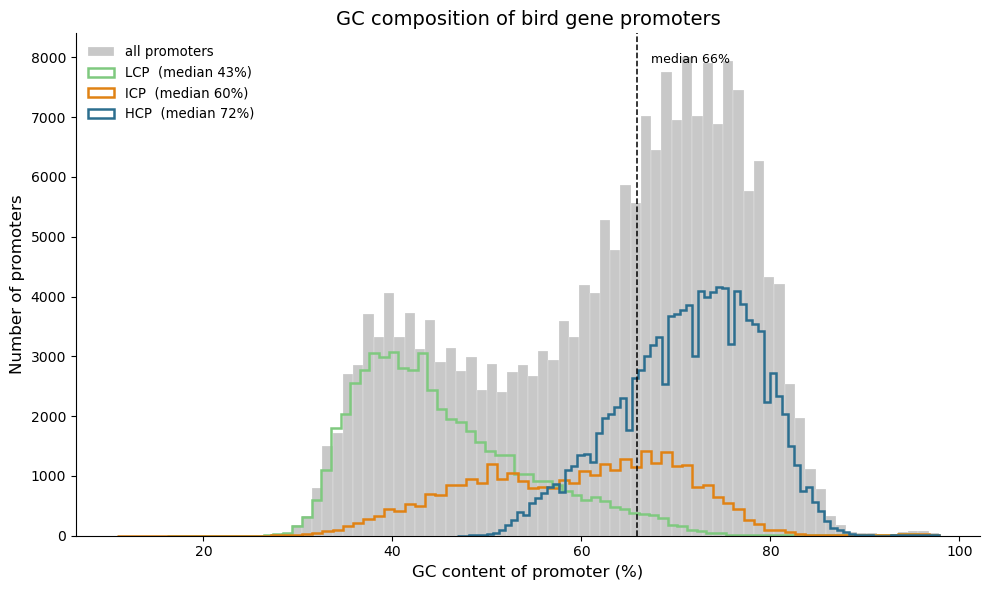

In [56]:
import numpy as np
import matplotlib.pyplot as plt

def plot_gc_content(
    df,
    gc_col='gc_content_pct',
    class_col='promoter_class_weber',
    bins=80,
):
    """Распределение GC-контента (%) промоторов, с разбивкой по классам Weber."""
    COL = {"LCP": "#7FC97F", "ICP": "#E08214", "HCP": "#2C6E8F"}  # LCP — светло-зелёный
    ORDER = ["LCP", "ICP", "HCP"]

    g = df[gc_col]
    fig, ax = plt.subplots(figsize=(10, 6))

    # общее распределение — серым фоном
    ax.hist(g, bins=bins, color="#9C9C9C", alpha=0.55,
            edgecolor="white", linewidth=0.3, label="all promoters")

    # контуры по классам
    for cls in ORDER:
        s = df.loc[df[class_col] == cls, gc_col]
        ax.hist(s, bins=bins, histtype="step", linewidth=1.8,
                color=COL[cls], label=f"{cls}  (median {s.median():.0f}%)")

    med = g.median()
    ax.axvline(med, color="black", lw=1.1, ls="--")
    ax.text(med + 1.5, ax.get_ylim()[1] * 0.96,
            f"median {med:.0f}%", fontsize=9, va="top")

    ax.set_xlabel("GC content of promoter (%)", fontsize=12)
    ax.set_ylabel("Number of promoters", fontsize=12)
    ax.set_title("GC composition of bird gene promoters", fontsize=14)
    ax.legend(frameon=False, loc="upper left", fontsize=9.5)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()


plot_gc_content(df=plot_df)

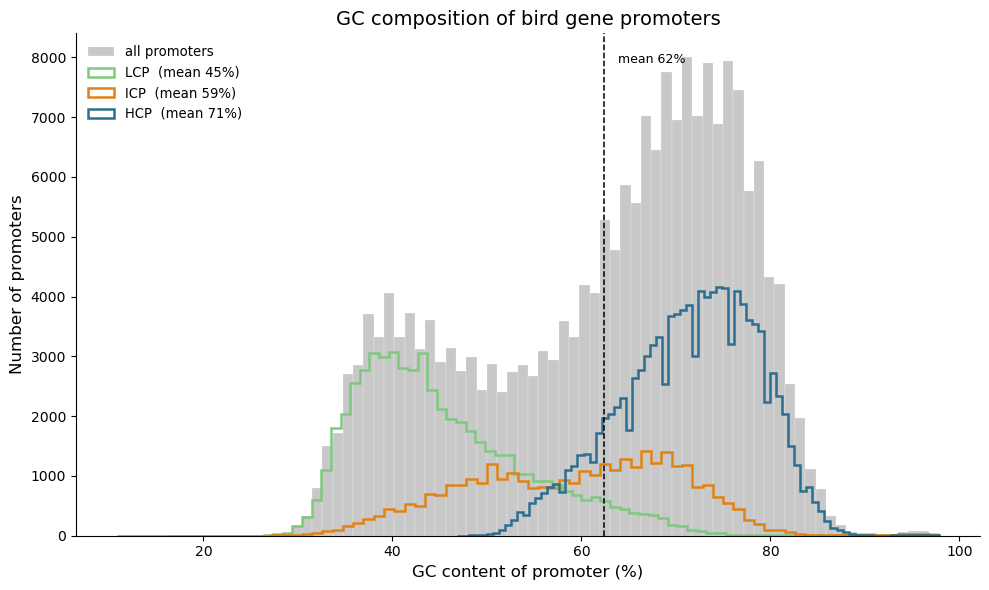

In [57]:
import numpy as np
import matplotlib.pyplot as plt

def plot_gc_content(
    df,
    gc_col='gc_content_pct',
    class_col='promoter_class_weber',
    bins=80,
):
    """Распределение GC-контента (%) промоторов, с разбивкой по классам Weber."""
    COL = {"LCP": "#7FC97F", "ICP": "#E08214", "HCP": "#2C6E8F"}  # LCP — светло-зелёный
    ORDER = ["LCP", "ICP", "HCP"]

    g = df[gc_col]
    fig, ax = plt.subplots(figsize=(10, 6))

    # общее распределение — серым фоном
    ax.hist(g, bins=bins, color="#9C9C9C", alpha=0.55,
            edgecolor="white", linewidth=0.3, label="all promoters")

    # контуры по классам
    for cls in ORDER:
        s = df.loc[df[class_col] == cls, gc_col]
        ax.hist(s, bins=bins, histtype="step", linewidth=1.8,
                color=COL[cls], label=f"{cls}  (mean {s.mean():.0f}%)")

    mean_gc = g.mean()
    ax.axvline(mean_gc, color="black", lw=1.1, ls="--")
    ax.text(mean_gc + 1.5, ax.get_ylim()[1] * 0.96,
            f"mean {mean_gc:.0f}%", fontsize=9, va="top")

    ax.set_xlabel("GC content of promoter (%)", fontsize=12)
    ax.set_ylabel("Number of promoters", fontsize=12)
    ax.set_title("GC composition of bird gene promoters", fontsize=14)
    ax.legend(frameon=False, loc="upper left", fontsize=9.5)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()


plot_gc_content(df=plot_df)